# Deep Momentum — Full Pipeline Run

Replication of Han & Qin (2026), "Bimodality Everywhere: International Evidence of Deep Momentum"

Pilot run: US, Canada, Australia

In [1]:
!pip install -q "pandas>=2.0" "numpy>=1.24" "xgboost>=2.0,<2.1" "scikit-learn>=1.3" requests python-dotenv pyarrow tqdm matplotlib seaborn yfinance


In [2]:
import warnings
warnings.filterwarnings('ignore')

PILOT_COUNTRIES = ['TO', 'OL', 'AT']  # Canada, Norway, Austria
N_ENSEMBLE = 100  # paper uses 100
OOS_START = '2010-01-31'  # paper's OOS start

print('Pilot countries:', PILOT_COUNTRIES)
print(f'Ensemble size: {N_ENSEMBLE}')

Pilot countries: ['TO', 'OL', 'AT']
Ensemble size: 100


## Step 1: Data Fetch

## Step 2: Data Filtering

In [3]:
from data_filter import filter_country, check_country_eligibility
from config import COUNTRIES, DATA_DIR, CACHE_DIR
from pathlib import Path
import pandas as pd

for suffix in PILOT_COUNTRIES:
    _, country_name, _, _ = COUNTRIES[suffix]
    f = Path(DATA_DIR) / f'monthly_{suffix}.parquet'
    if not f.exists():
        print(f'No data for {suffix}')
        continue
    df = pd.read_parquet(f)
    filtered = filter_country(df, country_name)
    filtered.to_parquet(Path(CACHE_DIR) / f'filtered_{suffix}.parquet', index=False)
    eligible, reason = check_country_eligibility(filtered, suffix)
    print(f'  Eligible: {eligible} — {reason}')


  Canada: 848 stocks, 191116 obs
    Zero volume filter: dropped 877 obs (0.5%)
    MCap missing filter: dropped 958 obs (0.5%)
    MCap bottom 5% filter: dropped 9624 obs (5.1%)
    Extreme return filter: dropped 93 obs (0.1%)
    Winsorize: clipped 3574 obs at [-0.3548, 0.6248]
    After all filters: 845 stocks, 178716 obs
  Eligible: False — min stocks/month = 2, need >=30

  Norway: 307 stocks, 48810 obs
    Zero volume filter: dropped 186 obs (0.4%)
    MCap missing filter: dropped 465 obs (1.0%)
    MCap bottom 5% filter: dropped 2518 obs (5.3%)
    Extreme return filter: dropped 43 obs (0.1%)
    Winsorize: clipped 906 obs at [-0.3846, 0.5370]
    After all filters: 304 stocks, 45291 obs
  Eligible: False — min stocks/month = 6, need >=30

  Austria: 98 stocks, 29173 obs
    Zero volume filter: dropped 291 obs (1.0%)
    MCap missing filter: dropped 404 obs (1.4%)
    MCap bottom 5% filter: dropped 1609 obs (5.7%)
    Extreme return filter: dropped 42 obs (0.2%)
    Winsorize: 

## Step 3: Feature Construction

In [4]:
from features import build_features
from config import COUNTRIES, CACHE_DIR
from pathlib import Path
import pandas as pd

cache_dir = Path(CACHE_DIR)
features_data = {}

for suffix in PILOT_COUNTRIES:
    filtered_path = cache_dir / f'filtered_{suffix}.parquet'
    if not filtered_path.exists():
        print(f'No filtered data for {suffix}, skipping')
        continue
    
    _, country_name, _, _ = COUNTRIES[suffix]
    df = pd.read_parquet(filtered_path)
    df, feature_cols = build_features(df, country_name)
    
    # Save
    df.to_parquet(cache_dir / f'features_{suffix}.parquet', index=False)
    features_data[suffix] = (df, feature_cols)
    
print(f'\nFeatures built for {len(features_data)} countries')
print(f'Feature columns ({len(feature_cols)}): {feature_cols}')

  Building features for Canada...
    Stocks: 845
    Total obs: 178716
    Complete obs (all features + label): 168637
    Feature cols: 16
  Building features for Norway...
    Stocks: 304
    Total obs: 45291
    Complete obs (all features + label): 41689
    Feature cols: 16
  Building features for Austria...
    Stocks: 97
    Total obs: 26729
    Complete obs (all features + label): 25574
    Feature cols: 16

Features built for 3 countries
Feature columns (16): ['zMOM_1', 'MMOM_1', 'SMOM_1', 'zMOM_3', 'MMOM_3', 'SMOM_3', 'zMOM_6', 'MMOM_6', 'SMOM_6', 'zMOM_9', 'MMOM_9', 'SMOM_9', 'zMOM_12', 'MMOM_12', 'SMOM_12', 'SIZE']


## Step 4: Model Training + Prediction

In [5]:
from model import run_walk_forward

predictions_data = {}

for suffix in PILOT_COUNTRIES:
    if suffix not in features_data:
        continue
    
    _, country_name, _, _ = COUNTRIES[suffix]
    df, feature_cols = features_data[suffix]
    
    print(f'\n{"="*60}')
    print(f'TRAINING: {country_name} (.{suffix})')
    print(f'{"="*60}')
    
    predictions = run_walk_forward(
        df, feature_cols,
        n_ensemble=N_ENSEMBLE,
        verbose=True,
    )
    
    if not predictions.empty:
        predictions.to_parquet(cache_dir / f'predictions_{suffix}.parquet', index=False)
        predictions_data[suffix] = predictions
        print(f'  Saved {len(predictions)} predictions')
    else:
        print(f'  No predictions generated')

print(f'\nPredictions generated for {len(predictions_data)} countries')


TRAINING: Canada (.TO)
    Training schedule: 27 retrainings
    First train: 2000-04-01
    Last train: 2026-04-01
    Training at 2000-04-01, predicting 12 months...
    Training at 2001-04-01, predicting 12 months...
    Training at 2002-04-01, predicting 12 months...
    Training at 2003-04-01, predicting 12 months...
    Training at 2004-04-01, predicting 12 months...
    Training at 2005-04-01, predicting 12 months...
    Training at 2006-04-01, predicting 12 months...
    Training at 2007-04-01, predicting 12 months...
    Training at 2008-04-01, predicting 12 months...
    Training at 2009-04-01, predicting 12 months...
    Training at 2010-04-01, predicting 12 months...
    Training at 2011-04-01, predicting 12 months...
    Training at 2012-04-01, predicting 12 months...
    Training at 2013-04-01, predicting 12 months...
    Training at 2014-04-01, predicting 12 months...
    Training at 2015-04-01, predicting 12 months...
    Training at 2016-04-01, predicting 12 months...

## Step 5: Portfolio Construction + Performance

In [6]:
from portfolio import run_all_strategies, print_performance_table

all_results = {}

for suffix in PILOT_COUNTRIES:
    if suffix not in features_data or suffix not in predictions_data:
        continue
    
    _, country_name, _, _ = COUNTRIES[suffix]
    df, feature_cols = features_data[suffix]
    predictions = predictions_data[suffix]
    
    # Merge fwd_return into predictions
    fwd = df[['symbol', 'date', 'fwd_return']].dropna()
    predictions = predictions.drop(columns=['fwd_return'], errors='ignore')
    predictions = predictions.merge(fwd, on=['symbol', 'date'], how='left')
    
    print(f'\n{"="*60}')
    print(f'{country_name}')
    print(f'{"="*60}')
    
    results = run_all_strategies(df, predictions, oos_start=OOS_START)
    print_performance_table(results)
    all_results[suffix] = results


Canada

Strategy      Ann.Ret    Ann.Vol   Sharpe    Cum.Ret    MaxDD   t-stat  Months   Avg TC
-----------------------------------------------------------------------------------
MOM            18.5%     24.2%    0.765   1122.3%  -40.9%     3.08     194    3.9bp
XGB            23.2%     13.9%    1.672   3330.3%  -14.3%     6.69     192    6.8bp
RET            32.8%     17.0%    1.921  14759.5%  -15.5%     7.72     194    9.5bp
SRP            32.3%     16.8%    1.922  13824.4%  -20.0%     7.73     194    9.9bp

Norway

Strategy      Ann.Ret    Ann.Vol   Sharpe    Cum.Ret    MaxDD   t-stat  Months   Avg TC
-----------------------------------------------------------------------------------
MOM            30.3%     26.5%    1.144   7243.9%  -34.3%     4.60     194    3.9bp
XGB            32.9%     20.6%    1.599  13336.3%  -26.1%     6.41     193    6.8bp
RET            32.3%     24.4%    1.323  10445.9%  -36.2%     5.31     193    9.7bp
SRP            33.5%     23.8%    1.406  12948.5% 

## Step 6: Full Report + Metrics

In [7]:
from metrics import full_report

for suffix in PILOT_COUNTRIES:
    if suffix not in features_data or suffix not in predictions_data:
        continue
    
    _, country_name, _, _ = COUNTRIES[suffix]
    df, feature_cols = features_data[suffix]
    predictions = predictions_data[suffix]
    
    # Merge fwd_return
    fwd = df[['symbol', 'date', 'fwd_return']].dropna()
    preds = predictions.drop(columns=['fwd_return'], errors='ignore')
    preds = preds.merge(fwd, on=['symbol', 'date'], how='left')
    
    full_report(df, preds, all_results.get(suffix, {}), country_name)


FULL REPORT — Canada

--- Portfolio Performance (Table 5 equivalent) ---
Strategy      Ann.Ret    Ann.Vol   Sharpe    Cum.Ret    MaxDD   t-stat  Months
---------------------------------------------------------------------------
MOM            18.5%     24.2%    0.765   1122.3%  -40.9%     3.08     194
XGB            23.2%     13.9%    1.672   3330.3%  -14.3%     6.69     192
RET            32.8%     17.0%    1.921  14759.5%  -15.5%     7.72     194
SRP            32.3%     16.8%    1.922  13824.4%  -20.0%     7.73     194

--- Bimodality (Table 2 equivalent) ---
  MOM:  HH=0.057  HL=0.030  LL=0.119  LH=0.074  BM=-0.036
  XGB:  HH=0.097  HL=0.069  LL=0.102  LH=0.064  BM=-0.033

--- Crash Rate ---
  MOM: 0.278
  XGB: 0.000
  RET: 0.000
  SRP: 0.000

--- Classification Accuracy (Table IA2 equivalent) ---
  Overall accuracy: 15.3%
  Precision H: 18.6%  Precision L: 19.7%
  Recall H: 25.4%  Recall L: 40.0%
  Pred ratio H: 13.6%  Pred ratio L: 20.8%

FULL REPORT — Norway

--- Portfolio Perf

## Plots

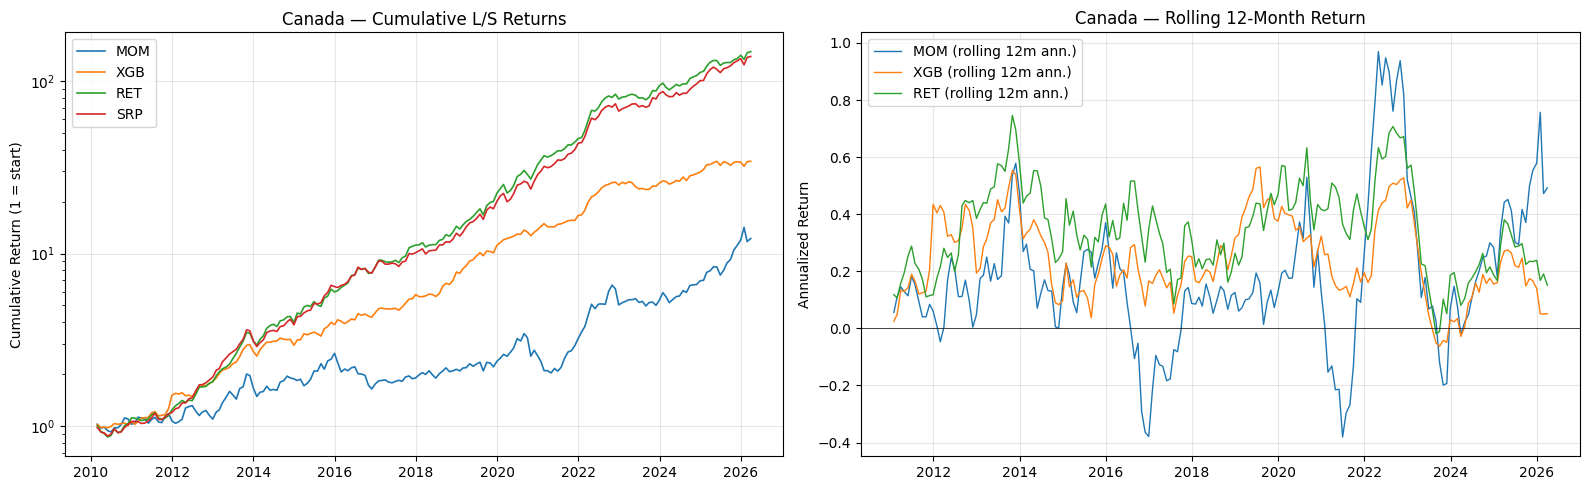

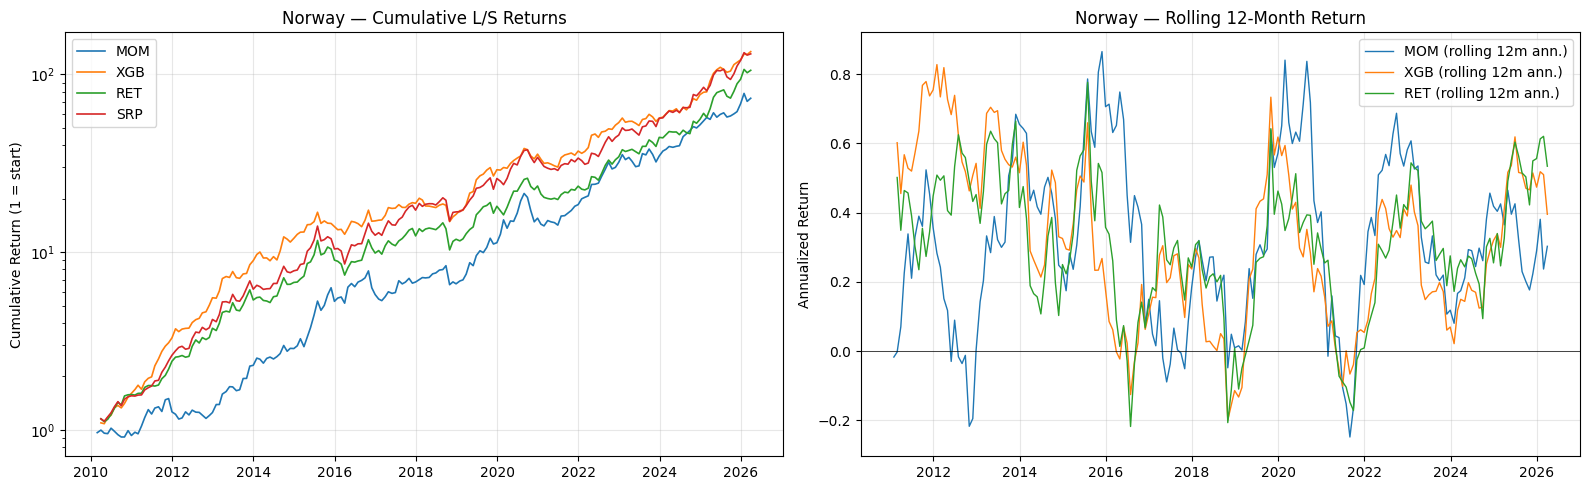

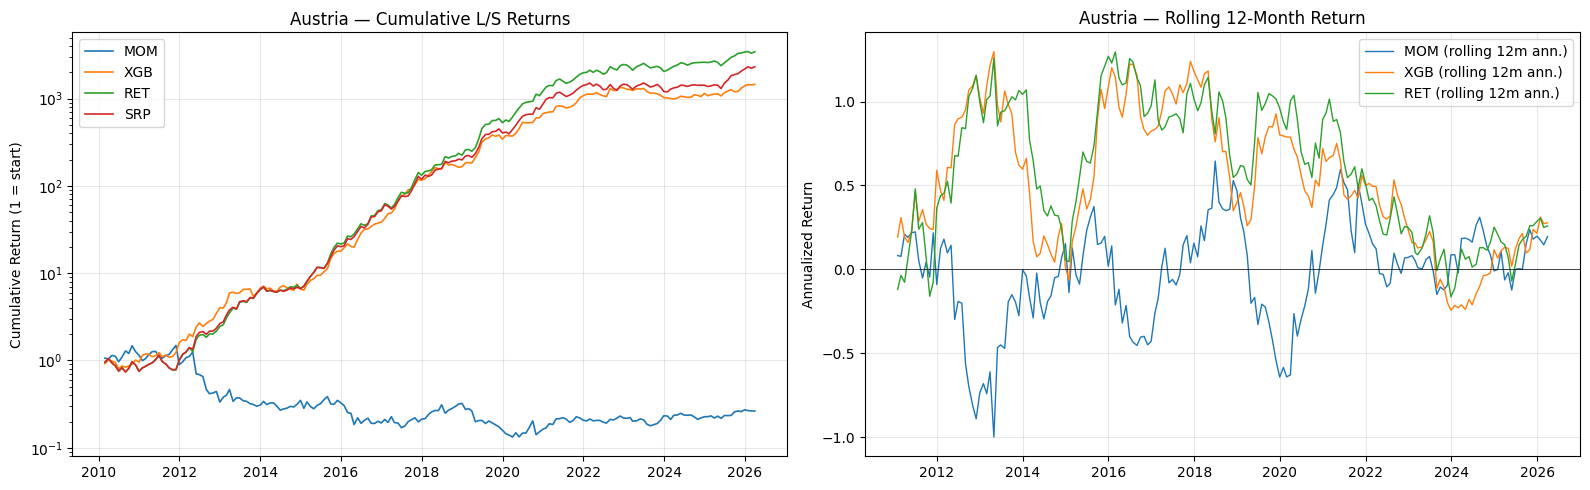

In [8]:
import matplotlib.pyplot as plt
import numpy as np

for suffix in PILOT_COUNTRIES:
    if suffix not in all_results:
        continue
    
    _, country_name, _, _ = COUNTRIES[suffix]
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Panel 1: Cumulative returns
    ax = axes[0]
    for name, color in [('MOM', '#1f77b4'), ('XGB', '#ff7f0e'), ('RET', '#2ca02c'), ('SRP', '#d62728')]:
        if name in all_results[suffix] and not all_results[suffix][name]['portfolio'].empty:
            port = all_results[suffix][name]['portfolio']
            cum = (1 + port['ls_ret']).cumprod()
            ax.plot(port['date'], cum, label=name, color=color, linewidth=1.2)
    
    ax.set_ylabel('Cumulative Return (1 = start)')
    ax.set_title(f'{country_name} — Cumulative L/S Returns')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_yscale('log')
    
    # Panel 2: Rolling 12-month return
    ax = axes[1]
    for name, color in [('MOM', '#1f77b4'), ('XGB', '#ff7f0e'), ('RET', '#2ca02c')]:
        if name in all_results[suffix] and not all_results[suffix][name]['portfolio'].empty:
            port = all_results[suffix][name]['portfolio']
            rolling = port['ls_ret'].rolling(12).mean() * 12
            ax.plot(port['date'], rolling, label=f'{name} (rolling 12m ann.)', 
                    color=color, linewidth=1)
    
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_ylabel('Annualized Return')
    ax.set_title(f'{country_name} — Rolling 12-Month Return')
    ax.legend()
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'results/{suffix}_performance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print()

## Cross-Country Comparison (Table 5 equivalent)

In [9]:
print(f'{"Country":<15s} {"":>5s} {"MOM":>12s} {"XGB":>12s} {"RET":>12s} {"SRP":>12s}')
print(f'{"":>20s} {"Ret / Sharpe":>12s} {"Ret / Sharpe":>12s} {"Ret / Sharpe":>12s} {"Ret / Sharpe":>12s}')
print('-' * 75)

for suffix in PILOT_COUNTRIES:
    if suffix not in all_results:
        continue
    _, country_name, _, _ = COUNTRIES[suffix]
    
    parts = [f'{country_name:<15s}', f'{"":>5s}']
    for name in ['MOM', 'XGB', 'RET', 'SRP']:
        if name in all_results[suffix] and all_results[suffix][name]['metrics']:
            m = all_results[suffix][name]['metrics']
            parts.append(f'{m["mean_annual"]:>5.1%}/{m["sharpe"]:>5.2f}')
        else:
            parts.append(f'{"N/A":>12s}')
    
    print('  '.join(parts))

Country                        MOM          XGB          RET          SRP
                     Ret / Sharpe Ret / Sharpe Ret / Sharpe Ret / Sharpe
---------------------------------------------------------------------------
Canada                  18.5%/ 0.77  23.2%/ 1.67  32.8%/ 1.92  32.3%/ 1.92
Norway                  30.3%/ 1.14  32.9%/ 1.60  32.3%/ 1.32  33.5%/ 1.41
Austria                 -1.0%/-0.03  50.0%/ 1.68  56.1%/ 1.76  53.4%/ 1.73


## Fixed-N Variant — Top 10 / Bottom 10 per Country per Month

Paper uses decile cuts (top/bottom 10%), which scales the portfolio with universe size. For practical execution we re-run all four strategies selecting a **fixed number** of names per country-month, ranked by each strategy's scalar signal:

- **MOM** — sort by `MOM_12`
- **XGB** — sort by `prob_10 − prob_1` (symmetric analogue of its class-based rule)
- **RET** — sort by `ret_score`
- **SRP** — sort by `srp_score`

Transaction costs (`TC_BPS = 15` one-way) are already applied inside `compute_turnover_cost`.

In [10]:
from portfolio import run_all_strategies, print_performance_table
from config import TOP_N_FIXED

all_results_fixed = {}

for suffix in PILOT_COUNTRIES:
    if suffix not in features_data or suffix not in predictions_data:
        continue

    _, country_name, _, _ = COUNTRIES[suffix]
    df, feature_cols = features_data[suffix]
    predictions = predictions_data[suffix]

    # Merge fwd_return into predictions (same as decile pass)
    fwd = df[['symbol', 'date', 'fwd_return']].dropna()
    predictions = predictions.drop(columns=['fwd_return'], errors='ignore')
    predictions = predictions.merge(fwd, on=['symbol', 'date'], how='left')

    print(f'\n{"="*60}')
    print(f'{country_name} — Fixed N={TOP_N_FIXED}')
    print(f'{"="*60}')

    results = run_all_strategies(df, predictions, oos_start=OOS_START, top_n=TOP_N_FIXED)
    print_performance_table(results)
    all_results_fixed[suffix] = results



Canada — Fixed N=5

Strategy      Ann.Ret    Ann.Vol   Sharpe    Cum.Ret    MaxDD   t-stat  Months   Avg TC
-----------------------------------------------------------------------------------
MOM            24.4%     54.8%    0.445    333.0%  -74.0%     1.79     194    6.7bp
XGB            38.7%     49.2%    0.787   7241.9%  -65.3%     3.16     194   13.7bp
RET            63.7%     44.6%    1.427 533011.1%  -57.1%     5.74     194   13.8bp
SRP            56.6%     45.6%    1.242 164612.9%  -49.6%     4.99     194   13.9bp

Norway — Fixed N=5

Strategy      Ann.Ret    Ann.Vol   Sharpe    Cum.Ret    MaxDD   t-stat  Months   Avg TC
-----------------------------------------------------------------------------------
MOM            29.8%     45.3%    0.659   2271.7%  -56.0%     2.65     194    5.2bp
XGB            45.9%     46.1%    0.995  27442.9%  -64.6%     3.99     193   12.5bp
RET            41.1%     44.8%    0.917  13764.1%  -63.7%     3.68     193   12.5bp
SRP            41.1%     4

### Decile vs Fixed-N — Side-by-Side Sharpe Comparison

In [11]:
print(f'{"Country":<15s}  {"Strategy":<8s}  {"Decile Ret":>10s} {"Decile SR":>9s}  {"FixedN Ret":>10s} {"FixedN SR":>9s}  {"Delta SR":>8s}')
print('-' * 85)

for suffix in PILOT_COUNTRIES:
    if suffix not in all_results or suffix not in all_results_fixed:
        continue
    _, country_name, _, _ = COUNTRIES[suffix]

    for name in ['MOM', 'XGB', 'RET', 'SRP']:
        d = all_results[suffix].get(name, {}).get('metrics', {})
        f = all_results_fixed[suffix].get(name, {}).get('metrics', {})
        if not d or not f:
            continue
        delta = f['sharpe'] - d['sharpe']
        print(f'{country_name:<15s}  {name:<8s}  '
              f'{d["mean_annual"]:>9.1%} {d["sharpe"]:>9.3f}  '
              f'{f["mean_annual"]:>9.1%} {f["sharpe"]:>9.3f}  '
              f'{delta:>+8.3f}')
    print()


Country          Strategy  Decile Ret Decile SR  FixedN Ret FixedN SR  Delta SR
-------------------------------------------------------------------------------------
Canada           MOM           18.5%     0.765      24.4%     0.445    -0.321
Canada           XGB           23.2%     1.672      38.7%     0.787    -0.885
Canada           RET           32.8%     1.921      63.7%     1.427    -0.494
Canada           SRP           32.3%     1.922      56.6%     1.242    -0.680

Norway           MOM           30.3%     1.144      29.8%     0.659    -0.485
Norway           XGB           32.9%     1.599      45.9%     0.995    -0.604
Norway           RET           32.3%     1.323      41.1%     0.917    -0.406
Norway           SRP           33.5%     1.406      41.1%     0.940    -0.466

Austria          MOM           -1.0%    -0.029       1.2%     0.027    +0.055
Austria          XGB           50.0%     1.677      76.0%     1.872    +0.195
Austria          RET           56.1%     1.765      

### Turnover and Trade Count Check (Fixed-N)

With top-10 / bottom-10 per country each month, the *maximum* trades per rebalance is 20 per country (replacing every name). Below we show realised average turnover and the resulting trade count per country-year.

In [12]:
import numpy as np

print(f'{"Country":<15s}  {"Strategy":<8s}  {"Avg Turnover":>13s}  {"Avg TC (bps)":>13s}  {"Trades/yr":>10s}')
print('-' * 70)

for suffix in PILOT_COUNTRIES:
    if suffix not in all_results_fixed:
        continue
    _, country_name, _, _ = COUNTRIES[suffix]
    for name in ['MOM', 'XGB', 'RET', 'SRP']:
        port = all_results_fixed[suffix].get(name, {}).get('portfolio')
        if port is None or port.empty or 'tc' not in port.columns:
            continue
        # tc is the per-month fractional cost = avg_turnover * TC_BPS / 10000
        # So avg_turnover = tc * 10000 / TC_BPS
        from config import TC_BPS
        avg_turnover = port['tc'].mean() * 10000 / TC_BPS if TC_BPS else 0
        avg_tc_bps = port['tc'].mean() * 10000
        # Trades/yr per country = 2 legs * 10 names * avg_turnover * 12 months
        trades_per_year = 2 * TOP_N_FIXED * avg_turnover * 12
        print(f'{country_name:<15s}  {name:<8s}  {avg_turnover:>12.1%}  {avg_tc_bps:>12.1f}  {trades_per_year:>10.0f}')
    print()


Country          Strategy   Avg Turnover   Avg TC (bps)   Trades/yr
----------------------------------------------------------------------
Canada           MOM              44.6%           6.7          54
Canada           XGB              91.6%          13.7         110
Canada           RET              91.9%          13.8         110
Canada           SRP              92.5%          13.9         111

Norway           MOM              34.4%           5.2          41
Norway           XGB              83.2%          12.5         100
Norway           RET              83.5%          12.5         100
Norway           SRP              84.1%          12.6         101

Austria          MOM              36.3%           5.4          44
Austria          XGB              81.2%          12.2          97
Austria          RET              84.0%          12.6         101
Austria          SRP              84.7%          12.7         102



## Section B: USD-base with FX Adjustment (5-5 per country)

Now view the same fixed-N=5 portfolios from the perspective of a **USD-base** investor. Each stock's forward return is converted to USD using Yahoo FX:

$$r^{USD}_{i,t\to t+1} = (1 + r^{local}_{i,t\to t+1}) \cdot (1 + \Delta FX_{t\to t+1}) - 1$$

On top of the 15 bps stock-trade cost we deduct an **FX roundtrip** of `FX_TC_BPS = 5` one-way on each rebalance's turnover.

In [13]:
from fx import build_fx_table, replace_fwd_return_with_usd

fx_table = build_fx_table(PILOT_COUNTRIES, start='1990-01-01')
for ccy, s in fx_table.items():
    n = s['fx_rate'].notna().sum()
    print(f'  {ccy}USD: {n} monthly obs, '
          f'{s["date"].min().date()} → {s["date"].max().date()}')


  Fetching FX: CADUSD
  Fetching FX: EURUSD
  Fetching FX: NOKUSD
  CADUSD: 272 monthly obs, 2003-09-30 → 2026-04-30
  EURUSD: 269 monthly obs, 2003-12-31 → 2026-04-30
  NOKUSD: 292 monthly obs, 2001-07-31 → 2026-04-30


In [14]:
from portfolio import run_all_strategies, print_performance_table, apply_fx_cost
from config import TOP_N_FIXED

all_results_usd = {}

for suffix in PILOT_COUNTRIES:
    if suffix not in features_data or suffix not in predictions_data:
        continue

    _, country_name, _, _ = COUNTRIES[suffix]
    df, feature_cols = features_data[suffix]
    predictions = predictions_data[suffix]

    # Merge local fwd_return into predictions (needed by portfolio ctor)
    fwd = df[['symbol', 'date', 'fwd_return']].dropna()
    preds = predictions.drop(columns=['fwd_return'], errors='ignore')
    preds = preds.merge(fwd, on=['symbol', 'date'], how='left')

    # Convert fwd_return → USD in both features and predictions DataFrames
    df_usd   = replace_fwd_return_with_usd(df, suffix, fx_table)
    preds_usd = replace_fwd_return_with_usd(preds, suffix, fx_table)

    print(f'\n{"="*60}')
    print(f'{country_name} — Fixed N={TOP_N_FIXED}, USD, FX-adj')
    print(f'{"="*60}')

    results = run_all_strategies(df_usd, preds_usd,
                                 oos_start=OOS_START,
                                 top_n=TOP_N_FIXED)

    # Deduct FX roundtrip cost from each strategy's ls_ret
    for name, rec in results.items():
        rec['portfolio'] = apply_fx_cost(rec['portfolio'])
        # Recompute metrics on net-of-FX return
        from portfolio import compute_performance
        rec['metrics'] = compute_performance(rec['portfolio'], name)

    print_performance_table(results)
    all_results_usd[suffix] = results



Canada — Fixed N=5, USD, FX-adj

Strategy      Ann.Ret    Ann.Vol   Sharpe    Cum.Ret    MaxDD   t-stat  Months   Avg TC
-----------------------------------------------------------------------------------
MOM            24.4%     54.8%    0.444    330.2%  -73.8%     1.79     194    6.7bp
XGB            38.6%     49.7%    0.778   6933.8%  -65.3%     3.13     194   13.7bp
RET            63.7%     44.9%    1.418 526603.6%  -57.0%     5.70     194   13.8bp
SRP            56.5%     45.9%    1.231 160080.2%  -49.2%     4.95     194   13.9bp

Norway — Fixed N=5, USD, FX-adj

Strategy      Ann.Ret    Ann.Vol   Sharpe    Cum.Ret    MaxDD   t-stat  Months   Avg TC
-----------------------------------------------------------------------------------
MOM            29.2%     45.4%    0.644   2024.9%  -57.5%     2.59     194    5.2bp
XGB            45.3%     46.0%    0.985  25242.6%  -64.8%     3.95     193   12.5bp
RET            41.1%     44.8%    0.916  13675.1%  -63.2%     3.67     193   12.5bp


### Local vs USD Sharpe Comparison

In [15]:
print(f'{"Country":<15s}  {"Strategy":<8s}  '
      f'{"Local Ret":>10s} {"Local SR":>9s}  '
      f'{"USD Ret":>9s} {"USD SR":>8s}  {"Delta SR":>8s}')
print('-' * 85)

for suffix in PILOT_COUNTRIES:
    if suffix not in all_results_fixed or suffix not in all_results_usd:
        continue
    _, country_name, _, _ = COUNTRIES[suffix]
    for name in ['MOM', 'XGB', 'RET', 'SRP']:
        loc = all_results_fixed[suffix].get(name, {}).get('metrics', {})
        usd = all_results_usd[suffix].get(name, {}).get('metrics', {})
        if not loc or not usd:
            continue
        delta = usd['sharpe'] - loc['sharpe']
        print(f'{country_name:<15s}  {name:<8s}  '
              f'{loc["mean_annual"]:>9.1%} {loc["sharpe"]:>9.3f}  '
              f'{usd["mean_annual"]:>8.1%} {usd["sharpe"]:>8.3f}  '
              f'{delta:>+8.3f}')
    print()


Country          Strategy   Local Ret  Local SR    USD Ret   USD SR  Delta SR
-------------------------------------------------------------------------------------
Canada           MOM           24.4%     0.445     24.4%    0.444    -0.001
Canada           XGB           38.7%     0.787     38.6%    0.778    -0.009
Canada           RET           63.7%     1.427     63.7%    1.418    -0.009
Canada           SRP           56.6%     1.242     56.5%    1.231    -0.011

Norway           MOM           29.8%     0.659     29.2%    0.644    -0.015
Norway           XGB           45.9%     0.995     45.3%    0.985    -0.010
Norway           RET           41.1%     0.917     41.1%    0.916    -0.001
Norway           SRP           41.1%     0.940     40.9%    0.934    -0.006

Austria          MOM            1.2%     0.027      0.5%    0.010    -0.016
Austria          XGB           76.0%     1.872     75.4%    1.853    -0.019
Austria          RET           67.5%     1.622     67.1%    1.607    -0.01

## Section C: Combined 30-Asset Global Portfolio (5L/5S × 3 countries, USD, FX-adj)

Each month, take each country's 5-long / 5-short selection and pool them into one **equal-weighted, 30-name, L/S book**. Monthly USD return equals the simple mean of the three country L/S returns (mathematically identical to 1/15 per name on each leg when every country contributes 5 names). Each country's return is already net of stock TC (15 bps) and FX roundtrip (5 bps).

In [16]:
import pandas as pd
import numpy as np
from portfolio import compute_performance

combined_results = {}

for name in ['MOM', 'XGB', 'RET', 'SRP']:
    # Collect each country's ls_ret series keyed on date
    per_country = []
    for suffix in PILOT_COUNTRIES:
        if suffix not in all_results_usd:
            continue
        port = all_results_usd[suffix].get(name, {}).get('portfolio')
        if port is None or port.empty:
            continue
        per_country.append(
            port[['date', 'ls_ret']].rename(columns={'ls_ret': f'ls_{suffix}'})
        )

    if len(per_country) < 2:
        continue

    merged = per_country[0]
    for p in per_country[1:]:
        merged = merged.merge(p, on='date', how='outer')
    merged = merged.sort_values('date').reset_index(drop=True)

    # Combined monthly return = mean across countries available that month
    ls_cols = [c for c in merged.columns if c.startswith('ls_')]
    merged['ls_ret'] = merged[ls_cols].mean(axis=1, skipna=True)
    merged = merged.dropna(subset=['ls_ret'])

    combined_results[name] = {
        'portfolio': merged,
        'metrics':   compute_performance(merged, name),
    }

print(f'\n{"="*60}')
print(f'COMBINED 30-ASSET PORTFOLIO ({" + ".join(PILOT_COUNTRIES)}), USD, FX-adj')
print(f'{"="*60}')
print(f'{"Strategy":<10s} {"Ann.Ret":>10s} {"Ann.Vol":>10s} {"Sharpe":>8s} '
      f'{"Cum.Ret":>10s} {"MaxDD":>8s} {"t-stat":>8s} {"Months":>7s}')
print('-' * 75)
for name in ['MOM', 'XGB', 'RET', 'SRP']:
    if name not in combined_results:
        continue
    m = combined_results[name]['metrics']
    print(f'{name:<10s} {m["mean_annual"]:>9.1%} {m["std_annual"]:>9.1%} '
          f'{m["sharpe"]:>8.3f} {m["cum_return"]:>9.1%} '
          f'{m["max_drawdown"]:>7.1%} {m["t_stat"]:>8.2f} {m["n_months"]:>7d}')



COMBINED 30-ASSET PORTFOLIO (TO + OL + AT), USD, FX-adj
Strategy      Ann.Ret    Ann.Vol   Sharpe    Cum.Ret    MaxDD   t-stat  Months
---------------------------------------------------------------------------
MOM            17.0%     32.7%    0.519    664.7%  -59.0%     2.18     212
XGB            51.7%     29.1%    1.774 374145.2%  -35.8%     7.46     212
RET            56.8%     29.6%    1.921 872706.9%  -38.9%     8.07     212
SRP            53.9%     30.4%    1.775 516623.7%  -38.1%     7.46     212


### Equity Curves — Combined Portfolio

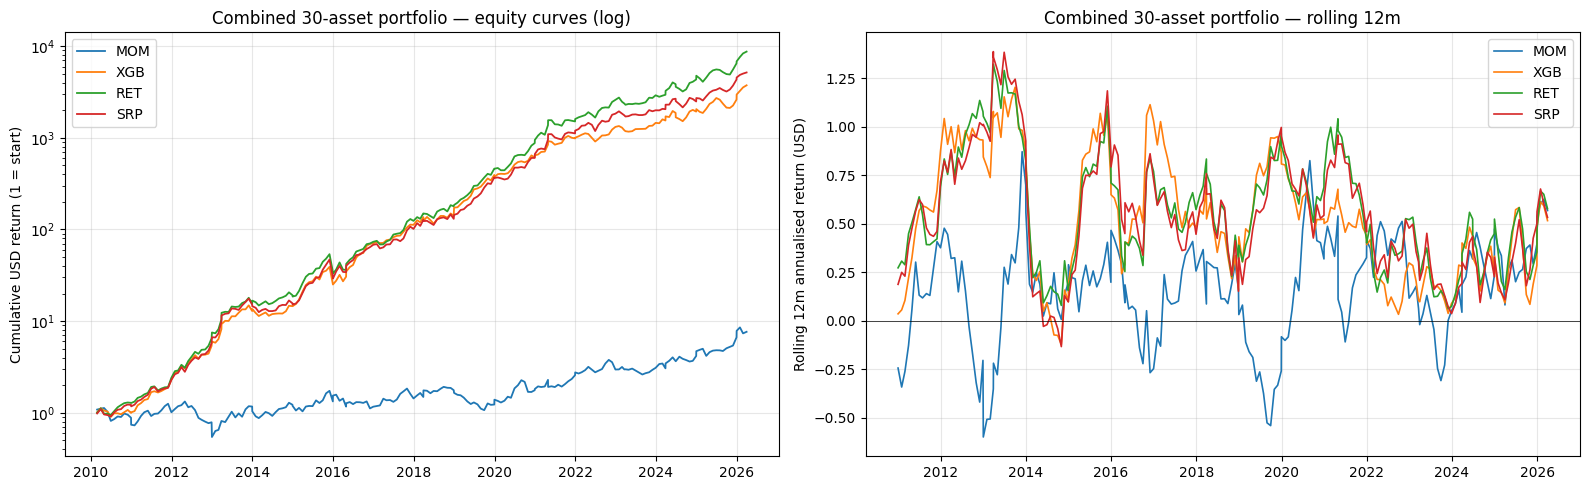

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = {'MOM': '#1f77b4', 'XGB': '#ff7f0e', 'RET': '#2ca02c', 'SRP': '#d62728'}

ax = axes[0]
for name, c in colors.items():
    if name not in combined_results:
        continue
    port = combined_results[name]['portfolio']
    cum = (1 + port['ls_ret']).cumprod()
    ax.plot(port['date'], cum, label=name, color=c, linewidth=1.3)
ax.set_yscale('log')
ax.set_ylabel('Cumulative USD return (1 = start)')
ax.set_title('Combined 30-asset portfolio — equity curves (log)')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
for name, c in colors.items():
    if name not in combined_results:
        continue
    port = combined_results[name]['portfolio']
    roll = port['ls_ret'].rolling(12).mean() * 12
    ax.plot(port['date'], roll, label=name, color=c, linewidth=1.2)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Rolling 12m annualised return (USD)')
ax.set_title('Combined 30-asset portfolio — rolling 12m')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/combined_usd_equity.png', dpi=150, bbox_inches='tight')
plt.show()


Strategy    Equity Ann    FX Ann  Total USD Ann   FX share
------------------------------------------------------------
MOM             17.4%    -0.4%         17.0%     -2.5%
XGB             52.1%    -0.4%         51.7%     -0.8%
RET             56.9%    -0.1%         56.8%     -0.2%
SRP             54.1%    -0.2%         53.9%     -0.3%


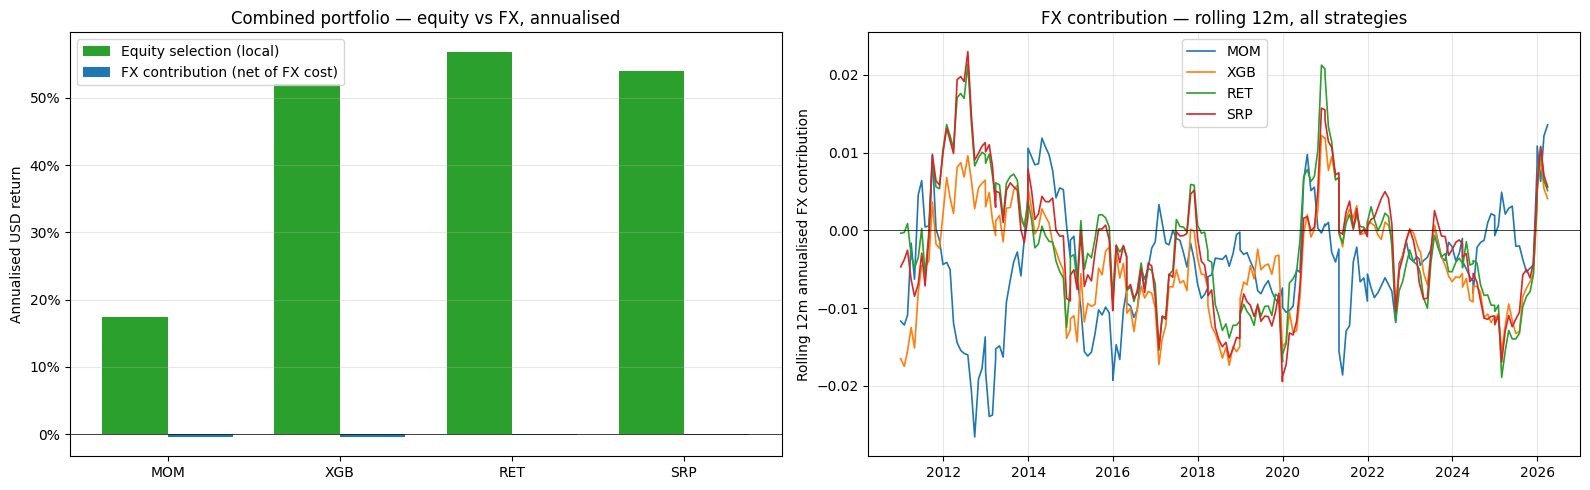

In [19]:
# ─── Source-of-returns decomposition: equity selection vs FX ────────────
# For a market-neutral L/S: r_USD = (1 + fx) * r_local
# So FX contribution (net of FX cost) = r_usd_combined - r_local_combined.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

decomp = {}
for name in ['MOM', 'XGB', 'RET', 'SRP']:
    # Combined local return = mean of each country's local L/S (Section A)
    parts = []
    for suffix in PILOT_COUNTRIES:
        port = all_results_fixed.get(suffix, {}).get(name, {}).get('portfolio')
        if port is None or port.empty:
            continue
        parts.append(port[['date', 'ls_ret']].rename(columns={'ls_ret': f'ls_{suffix}'}))
    if len(parts) < 2 or name not in combined_results:
        continue
    m = parts[0]
    for p in parts[1:]:
        m = m.merge(p, on='date', how='outer')
    m['r_local'] = m[[c for c in m.columns if c.startswith('ls_')]].mean(axis=1, skipna=True)
    m = m[['date', 'r_local']].dropna()

    usd = combined_results[name]['portfolio'][['date', 'ls_ret']].rename(columns={'ls_ret': 'r_usd'})
    d = m.merge(usd, on='date', how='inner').sort_values('date').reset_index(drop=True)
    d['r_fx'] = d['r_usd'] - d['r_local']
    decomp[name] = d

# ─── Summary table ──────────────────────────────────────────────────────
print(f'{"Strategy":<10s} {"Equity Ann":>11s} {"FX Ann":>9s} {"Total USD Ann":>14s} {"FX share":>10s}')
print('-' * 60)
for name, d in decomp.items():
    eq  = d['r_local'].mean() * 12
    fx_ = d['r_fx'].mean() * 12
    tot = d['r_usd'].mean() * 12
    share = fx_ / tot if abs(tot) > 1e-9 else np.nan
    print(f'{name:<10s} {eq:>10.1%} {fx_:>8.1%} {tot:>13.1%} {share:>9.1%}')

# ─── Visualisation ──────────────────────────────────────────────────────
colors = {'MOM': '#1f77b4', 'XGB': '#ff7f0e', 'RET': '#2ca02c', 'SRP': '#d62728'}
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: grouped bar chart — annualised equity vs FX per strategy
ax = axes[0]
names = list(decomp.keys())
x = np.arange(len(names))
eq_ann = [decomp[n]['r_local'].mean() * 12 for n in names]
fx_ann = [decomp[n]['r_fx'].mean() * 12 for n in names]
w = 0.38
ax.bar(x - w/2, eq_ann, w, label='Equity selection (local)', color='#2ca02c')
ax.bar(x + w/2, fx_ann, w, label='FX contribution (net of FX cost)', color='#1f77b4')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel('Annualised USD return')
ax.set_title('Combined portfolio — equity vs FX, annualised')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.legend(); ax.grid(alpha=0.3, axis='y')

# Right: rolling 12m FX contribution — one line per strategy
ax = axes[1]
for name, d in decomp.items():
    roll = d['r_fx'].rolling(12).mean() * 12
    ax.plot(d['date'], roll, label=name, color=colors[name], linewidth=1.2)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Rolling 12m annualised FX contribution')
ax.set_title('FX contribution — rolling 12m, all strategies')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/combined_usd_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()